# gas_drift_project.ipynb

**Dreifuojančių dujų jutiklių klasifikavimas — UCI "Gas Sensor Array Drift Dataset"**

Praktinė realizacija pagal planavimo dokumentą `DISfm-26_Tauras_Rimdzius.docx`
(A priedas: Numatoma notebook'o struktūra). Skyrių numeracija ir pavadinimai
žemiau atkartoja dokumento 2 ir 5 skyrių struktūrą bei ten nurodytus modulių
pavadinimus (jie žymi loginius šio notebook'o skyrius, o ne atskirus .py failus).

Autorius: Tauras Rimdžius · Intelektualiosios sistemos · VilniusTech

## 0. Įvadas ir aplinkos paruošimas

**Diegimas ir paleidimas**

1. Priklausomybės: `pip install -r requirements.txt` (numpy, pandas, scipy,
   scikit-learn, matplotlib — tikslios versijos nurodytos faile).
2. Duomenys: `Dataset/batch1.dat` … `batch10.dat` (UCI originalūs libsvm formato
   failai) turi būti šalia notebook'o esančiame `Dataset/` aplanke — jie pridėti
   kartu su pateikimu, atsisiųsti papildomai nereikia. Jei jų nėra, atsisiųsti iš
   https://archive.ics.uci.edu/dataset/224/gas+sensor+array+drift+dataset ir
   išpakuoti į `Dataset/`.
3. Fiksuotas atsitiktinumo generatoriaus sėkla: `RANDOM_SEED = 42` nustatoma
   pirmame kodo langelyje ir naudojama visur (`train_test_split`, `SVC(random_state=...)`,
   nepažymėtų mėginių atrinkimas ir kt.) — atkuriamumui.
4. **Viena komanda pagrindiniam eksperimentui pakartoti** (paleidžia visą notebook'ą
   nuo pradžios iki galo, įskaitant duomenų įkėlimą, visus tris modelius —
   kNN, SVM (RBF), CORAL+tiesinis SVM — abliacijas ir grafikus):

   ```bash
   jupyter nbconvert --to notebook --execute gas_drift_project.ipynb \
       --output gas_drift_project_executed.ipynb --ExecutePreprocessor.timeout=1800
   ```

   (jei aplinkoje nėra `jupyter`, langelius galima paleisti rankiniu būdu iš eilės
   Jupyter/JupyterLab/VS Code sąsajoje — kodas nuo pirmo iki paskutinio langelio
   nepriklauso nuo jokio išorinio skripto, viskas viename faile.)

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.datasets import load_svmlight_file
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (f1_score, precision_score, recall_score,
                              confusion_matrix, classification_report,
                              brier_score_loss)
from scipy.stats import wilcoxon, linregress, skew

import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['figure.dpi'] = 110
matplotlib.rcParams['axes.grid'] = True
matplotlib.rcParams['grid.alpha'] = 0.3

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Vienodos spalvos kiekvienam metodui VISUOSE grafikuose (aiškumui iš pirmo žvilgsnio)
MODEL_COLORS = {
    'kNN + standartizavimas': 'tab:blue',
    'kNN+standartizavimas': 'tab:blue',
    'CORAL + tiesinis SVM': 'tab:orange',
    'CORAL+tiesinis SVM': 'tab:orange',
    'SVM (tiesinis), be CORAL': 'tab:green',
    'SVM (RBF)': 'tab:red',
    'SVM(RBF)': 'tab:red',
}

DATA_DIR = Path('Dataset')
N_FEATURES = 128
N_SENSORS = 16
FEATURES_PER_SENSOR = 8
FEATURE_COLS = [f'f{i+1}' for i in range(N_FEATURES)]

GAS_NAMES = {1: 'Etanolis', 2: 'Etilenas', 3: 'Amoniakas',
             4: 'Acetaldehidas', 5: 'Acetonas', 6: 'Toluenas'}
CLASSES = sorted(GAS_NAMES.keys())
AMMONIA_LABEL = 3  # didžiausios saugos svarbos dujos (1.6 sk.)

print(f"Fiksuotas random seed: {RANDOM_SEED}")
print(f"Numatomi požymiai: {N_FEATURES} (16 jutiklių x 8 požymiai/jutikliui)")
print("Dujų klasės:", GAS_NAMES)

Fiksuotas random seed: 42
Numatomi požymiai: 128 (16 jutiklių x 8 požymiai/jutikliui)
Dujų klasės: {1: 'Etanolis', 2: 'Etilenas', 3: 'Amoniakas', 4: 'Acetaldehidas', 5: 'Acetonas', 6: 'Toluenas'}


## 1. Duomenų gavimas

`load_batches()` — libsvm sparse formato `batch1.dat`...`batch10.dat` (UCI
originalūs failai) įkėlimas ir sujungimas į vieningą lentelę
[1 etapas / `data/loader.py` atitikmuo].

In [2]:
def load_batches(data_dir=DATA_DIR, n_batches=10, n_features=N_FEATURES):
    """Įkelia UCI Gas Sensor Array Drift batch*.dat (libsvm sparse formatas)
    ir sujungia į vieningą DataFrame: sample_id, batch, gas_label, f1..f128."""
    frames = []
    for b in range(1, n_batches + 1):
        path = data_dir / f'batch{b}.dat'
        X, y = load_svmlight_file(str(path), n_features=n_features)
        df = pd.DataFrame(X.toarray(), columns=FEATURE_COLS)
        df.insert(0, 'batch', b)
        df.insert(1, 'gas_label', y.astype(int))
        frames.append(df)
    full = pd.concat(frames, ignore_index=True)
    full.insert(0, 'sample_id', np.arange(len(full)))
    return full

df_all = load_batches()
print(f"Iš viso mėginių: {len(df_all)}")
print(f"Požymių: {len(FEATURE_COLS)}, paketų: {df_all['batch'].nunique()}")
assert df_all[FEATURE_COLS].isna().sum().sum() == 0, "Rasta trūkstamų reikšmių!"
df_all.head()

Iš viso mėginių: 13910
Požymių: 128, paketų: 10


**Patikra pagal dokumento 2.1 lentelę** (Fonollosa, Rodríguez-Luján, Huerta,
2015) — mėginių skaičius per paketą ir dujų klasę turi sutapti su planavimo
dokumente pateikta lentele.

In [3]:
summary = df_all.pivot_table(index='batch', columns='gas_label',
                               values='sample_id', aggfunc='count', fill_value=0)
for c in CLASSES:
    if c not in summary.columns:
        summary[c] = 0
summary = summary[CLASSES]
summary.columns = [GAS_NAMES[c] for c in CLASSES]
summary['Iš viso'] = summary.sum(axis=1)
summary

In [4]:
expected_totals = {1: 445, 2: 1244, 3: 1586, 4: 161, 5: 197,
                   6: 2300, 7: 3613, 8: 294, 9: 470, 10: 3600}
all_ok = True
for b, exp in expected_totals.items():
    actual = int(summary.loc[b, 'Iš viso'])
    ok = actual == exp
    all_ok &= ok
    print(f"Paketas {b:2d}: laukta {exp:5d}, gauta {actual:5d} -> {'OK' if ok else 'NEATITINKA'}")
print(f"\nBendra suma: {int(summary['Iš viso'].sum())} (dokumente nurodyta: 13910)")
assert all_ok and int(summary['Iš viso'].sum()) == 13910
print("Duomenų įkėlimas patikrintas: sutampa su dokumento 2.1 lentele.")

Paketas  1: laukta   445, gauta   445 -> OK
Paketas  2: laukta  1244, gauta  1244 -> OK
Paketas  3: laukta  1586, gauta  1586 -> OK
Paketas  4: laukta   161, gauta   161 -> OK
Paketas  5: laukta   197, gauta   197 -> OK
Paketas  6: laukta  2300, gauta  2300 -> OK
Paketas  7: laukta  3613, gauta  3613 -> OK
Paketas  8: laukta   294, gauta   294 -> OK
Paketas  9: laukta   470, gauta   470 -> OK
Paketas 10: laukta  3600, gauta  3600 -> OK

Bendra suma: 13910 (dokumente nurodyta: 13910)
Duomenų įkėlimas patikrintas: sutampa su dokumento 2.1 lentele.


Paketuose 3–5 iš tiesų visiškai trūksta tolueno (6) klasės — tai patvirtina
dokumento 1.5/2.1/6.4 skyriuose minėtą apribojimą.

In [5]:
missing_toluene = [b for b in range(1, 11) if summary.loc[b, 'Toluenas'] == 0]
print("Paketai be tolueno klasės:", missing_toluene)
assert missing_toluene == [3, 4, 5]

Paketai be tolueno klasės: [3, 4, 5]


## 2. Duomenų paruošimas

`preprocess()` — trūkstamų reikšmių patikra (aukščiau), EDA (požymių
asimetriškumas), z-score standartizavimas (statistika tik iš mokymo paketų),
klasių balanso analizė, skaidymo protokolai
[2 etapas / `data/preprocessing.py` atitikmuo].

### 2.1 Požymių pogrupiai ir EDA (asimetriškumas)

Kiekvienam iš 16 jutiklių priskirti 8 požymiai: 1 pastovios būsenos (steady
-state) požymis + 7 EMA tranzientiniai požymiai (didėjančios/mažėjančios
fazės, α = 0.001/0.01/0.1). Toliau apibrėžiami požymių pogrupiai, naudojami
6.3 skyriaus abliacijoje.

In [6]:
STEADY_STATE_COLS = [FEATURE_COLS[i * FEATURES_PER_SENSOR] for i in range(N_SENSORS)]
EMA_TRANSIENT_COLS = [c for c in FEATURE_COLS if c not in STEADY_STATE_COLS]
assert len(STEADY_STATE_COLS) == 16 and len(EMA_TRANSIENT_COLS) == 112

skew_steady = df_all[STEADY_STATE_COLS].apply(skew)
skew_ema = df_all[EMA_TRANSIENT_COLS].apply(skew)
neg_frac_steady = (df_all[STEADY_STATE_COLS] < 0).mean().mean()
neg_frac_ema = (df_all[EMA_TRANSIENT_COLS] < 0).mean().mean()

print(f"Pastovios būsenos požymiai (n=16): |skew| vidurkis={skew_steady.abs().mean():.2f}, "
      f"maks={skew_steady.abs().max():.2f}, neigiamų reikšmių dalis={neg_frac_steady:.3f}")
print(f"EMA tranzientiniai požymiai (n=112): |skew| vidurkis={skew_ema.abs().mean():.2f}, "
      f"maks={skew_ema.abs().max():.2f}, neigiamų reikšmių dalis={neg_frac_ema:.3f}")

Pastovios būsenos požymiai (n=16): |skew| vidurkis=1.45, maks=2.67, neigiamų reikšmių dalis=0.004
EMA tranzientiniai požymiai (n=112): |skew| vidurkis=14.72, maks=117.92, neigiamų reikšmių dalis=0.429


EMA tranzientiniai požymiai turi neigiamų reikšmių (mažėjančios fazės
atsakas), todėl `log1p` jiems tiesiogiai netaikytinas. Pastovios būsenos
požymiai visada neneigiami, bet labai skirtingo mastelio tarp jutiklių
(dešimtys–šimtai tūkstančių) — sprendimas dėl `log1p` priimamas empiriškai.

In [7]:
APPLY_LOG1P_STEADY = bool((skew_steady.abs().mean() > 1.0) and (neg_frac_steady == 0))
print(f"Sprendimas: taikyti log1p pastovios būsenos požymiams? {APPLY_LOG1P_STEADY}")

df_proc = df_all.copy()
if APPLY_LOG1P_STEADY:
    df_proc[STEADY_STATE_COLS] = np.log1p(df_proc[STEADY_STATE_COLS])
    skew_after = df_proc[STEADY_STATE_COLS].apply(skew)
    print(f"|skew| vidurkis PO log1p: {skew_after.abs().mean():.2f} "
          f"(buvo {skew_steady.abs().mean():.2f})")
else:
    print("log1p netaikomas (kriterijus neįvykdytas).")

Sprendimas: taikyti log1p pastovios būsenos požymiams? False
log1p netaikomas (kriterijus neįvykdytas).


### 2.2 Klasių balansas

Klasių disbalansas sprendžiamas `class_weight='balanced'` + macro-F1 metrika,
NE dirbtiniu papildomu ėmimu (SMOTE tarp paketų neleidžiamas — 6.2 skyrius).

In [8]:
class_counts = df_proc['gas_label'].value_counts().sort_index()
class_counts.index = [GAS_NAMES[c] for c in class_counts.index]
print("Bendras klasių pasiskirstymas (visi paketai):")
class_counts

Bendras klasių pasiskirstymas (visi paketai):


### 2.3 Chronologiniai skaidymo protokolai (6.1 skyrius)

Joks atsitiktinis maišymas tarp paketų neleidžiamas.

In [9]:
def protocol_A_splits(n_batches=10):
    """Protokolas A: mokymas 1 pakete, testavimas kiekviename iš 2..n_batches
    atskirai (atkartoja Vergara et al., 2012)."""
    return [([1], t) for t in range(2, n_batches + 1)]

def protocol_B_splits(n_batches=10):
    """Protokolas B: plečiamas langas — mokymas 1..k, testavimas k+1
    ('test-then-train')."""
    return [(list(range(1, k + 1)), k + 1) for k in range(1, n_batches)]

splits_A = protocol_A_splits()
splits_B = protocol_B_splits()
print("Protokolas A (train -> test):", splits_A)
print("Protokolas B (train -> test):", splits_B)

Protokolas A (train -> test): [([1], 2), ([1], 3), ([1], 4), ([1], 5), ([1], 6), ([1], 7), ([1], 8), ([1], 9), ([1], 10)]
Protokolas B (train -> test): [([1], 2), ([1, 2], 3), ([1, 2, 3], 4), ([1, 2, 3, 4], 5), ([1, 2, 3, 4, 5], 6), ([1, 2, 3, 4, 5, 6], 7), ([1, 2, 3, 4, 5, 6, 7], 8), ([1, 2, 3, 4, 5, 6, 7, 8], 9), ([1, 2, 3, 4, 5, 6, 7, 8, 9], 10)]


Reprezentatyvus mėnesių žymėjimas kiekvienam paketui (kai kurie paketai
apima kelis, ne iš eilės einančius mėnesius — 2.1 lentelė; čia naudojamas
jų vidurkis kaip vienas reprezentatyvus laiko taškas `drift_slope()`
skaičiavimui, 5.4 skyrius).

In [10]:
BATCH_MONTHS = {
    1: np.mean([1, 2]), 2: np.mean([3, 4, 8, 9, 10]), 3: np.mean([11, 12, 13]),
    4: np.mean([14, 15]), 5: 16.0, 6: np.mean([17, 18, 19, 20]), 7: 21.0,
    8: np.mean([22, 23]), 9: np.mean([24, 30]), 10: 36.0,
}
print({b: round(m, 2) for b, m in BATCH_MONTHS.items()})

{1: np.float64(1.5), 2: np.float64(6.8), 3: np.float64(12.0), 4: np.float64(14.5), 5: 16.0, 6: np.float64(18.5), 7: 21.0, 8: np.float64(22.5), 9: np.float64(27.0), 10: 36.0}


### 2.4 `preprocess()` — formalus žingsnis

Standartizavimo statistika (μ, σ) kiekvieną kartą perskaičiuojama TIK iš to
momento mokymo aibės — ypač svarbu Protokole B, kad neįvyktų duomenų
nutekėjimas iš ateities.

In [11]:
def preprocess(df, train_batches, test_batch, feature_cols=None):
    feature_cols = feature_cols or FEATURE_COLS
    train = df[df['batch'].isin(train_batches)]
    test = df[df['batch'] == test_batch]
    scaler = StandardScaler().fit(train[feature_cols].values)
    Xtr = scaler.transform(train[feature_cols].values)
    Xte = scaler.transform(test[feature_cols].values)
    ytr = train['gas_label'].values
    yte = test['gas_label'].values
    return Xtr, ytr, Xte, yte, scaler

Xtr_demo, ytr_demo, Xte_demo, yte_demo, _ = preprocess(df_proc, [1], 2)
print(f"Pavyzdys (1->2): Xtr {Xtr_demo.shape}, Xte {Xte_demo.shape}")
print(f"Mokymo aibės vidurkis po standartizavimo (turi būti ~0): {Xtr_demo.mean():.2e}")
print(f"Mokymo aibės std po standartizavimo (turi būti ~1): {Xtr_demo.std():.4f}")

Pavyzdys (1->2): Xtr (445, 128), Xte (1244, 128)
Mokymo aibės vidurkis po standartizavimo (turi būti ~0): -7.55e-18
Mokymo aibės std po standartizavimo (turi būti ~1): 1.0000


## 3. Modeliai

### 3.1 kNN baseline

`fit_predict_knn()` — k artimiausių kaimynų su z-score standartizavimu
(5.1 formulės) [3.1 / 5.1 / `models/baseline_knn.py` atitikmuo].

In [12]:
def fit_predict_knn(df, train_batches, test_batch, k=5, standardize=True, feature_cols=None):
    feature_cols = feature_cols or FEATURE_COLS
    train = df[df['batch'].isin(train_batches)]
    test = df[df['batch'] == test_batch]
    Xtr_raw, ytr = train[feature_cols].values, train['gas_label'].values
    Xte_raw, yte = test[feature_cols].values, test['gas_label'].values
    if standardize:
        scaler = StandardScaler().fit(Xtr_raw)
        Xtr, Xte = scaler.transform(Xtr_raw), scaler.transform(Xte_raw)
    else:
        Xtr, Xte = Xtr_raw, Xte_raw
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(Xtr, ytr)
    y_pred = knn.predict(Xte)
    y_proba = knn.predict_proba(Xte)
    return dict(y_true=yte, y_pred=y_pred, y_proba=y_proba, classes=knn.classes_,
                n_train=len(ytr), n_test=len(yte))

def _holdout_split_single_batch(df, batch, feature_cols, test_size=0.3):
    sub = df[df['batch'] == batch]
    X, y = sub[feature_cols].values, sub['gas_label'].values
    return train_test_split(X, y, test_size=test_size, stratify=y, random_state=RANDOM_SEED)

def tune_k_time_sensitive(df, train_batches, k_grid=(1, 3, 5, 7, 9, 11, 15, 21, 31),
                            feature_cols=None, fallback_k=5):
    """Laikui jautri validacija (6.1 sk.): paskutinis chronologiškai vėliausias
    mokymo paketas atskiriamas validacijai. Jei mokymui yra tik 1 paketas
    (Protokolo A / B pirmas žingsnis), naudojamas atsitiktinis stratifikuotas
    to paties pakete padalinimas TIK derinimo tikslu — tikrieji testiniai
    paketai niekada nenaudojami derinimui (dokumentuota prielaida)."""
    feature_cols = feature_cols or FEATURE_COLS
    if len(train_batches) >= 2:
        val_batch, fit_batches = train_batches[-1], train_batches[:-1]
        best_k, best_f1 = fallback_k, -1
        for k in k_grid:
            res = fit_predict_knn(df, fit_batches, val_batch, k=k, standardize=True, feature_cols=feature_cols)
            f1 = f1_score(res['y_true'], res['y_pred'], average='macro')
            if f1 > best_f1:
                best_f1, best_k = f1, k
        return best_k
    Xtr, Xval, ytr, yval = _holdout_split_single_batch(df, train_batches[0], feature_cols)
    scaler = StandardScaler().fit(Xtr)
    Xtr_s, Xval_s = scaler.transform(Xtr), scaler.transform(Xval)
    best_k, best_f1 = fallback_k, -1
    for k in k_grid:
        knn = KNeighborsClassifier(n_neighbors=k).fit(Xtr_s, ytr)
        f1 = f1_score(yval, knn.predict(Xval_s), average='macro')
        if f1 > best_f1:
            best_f1, best_k = f1, k
    return best_k

k_star_demo = tune_k_time_sensitive(df_proc, [1])
print(f"Parinktas k (pavyzdys, mokymas tik iš 1 pakete): k={k_star_demo}")
res_demo = fit_predict_knn(df_proc, [1], 2, k=k_star_demo)
print("Macro-F1 (1->2 pavyzdys):", round(f1_score(res_demo['y_true'], res_demo['y_pred'], average='macro'), 4))

Parinktas k (pavyzdys, mokymas tik iš 1 pakete): k=1
Macro-F1 (1->2 pavyzdys): 0.6352


### 3.2 CORAL domeno adaptacija + tiesinis SVM — pagrindinis metodas

`fit_coral()`, `apply_coral()` + `fit_predict_svm_linear()` (5.3 formulės)
[3.5 / 5.3 / `models/domain_adaptation_coral.py` atitikmuo].

In [13]:
def _sym_matrix_power(M, power, eps_floor=1e-12):
    vals, vecs = np.linalg.eigh(M)
    vals = np.clip(vals, eps_floor, None)
    return (vecs * (vals ** power)) @ vecs.T

def fit_coral(D_S, D_T, eps=1e-3):
    """CORAL (Sun, Feng, Saenko, 2016): grąžina transformacijos matricą W
    tokia, kad D_S @ W turi tokią pačią antros eilės statistiką (kovariaciją)
    kaip D_T (5.3 formulės)."""
    n_S, n_T, d = D_S.shape[0], D_T.shape[0], D_S.shape[1]
    C_S = (D_S.T @ D_S) / (n_S - 1) + eps * np.eye(d)
    C_T = (D_T.T @ D_T) / (n_T - 1) + eps * np.eye(d)
    W = _sym_matrix_power(C_S, -0.5) @ _sym_matrix_power(C_T, 0.5)
    return W

def apply_coral(D, W):
    return D @ W

def fit_predict_svm_linear(D_S_prime, y_S, D_T, C=1.0, probability=True):
    svm = SVC(kernel='linear', C=C, probability=probability, class_weight='balanced',
              random_state=RANDOM_SEED, cache_size=1000)
    svm.fit(D_S_prime, y_S)
    y_pred = svm.predict(D_T)
    y_proba = svm.predict_proba(D_T) if probability else None
    return svm, y_pred, y_proba

def fit_predict_coral_svm(df, train_batches, test_batch, C=1.0, eps=1e-3,
                            n_unlabeled=None, probability=True, feature_cols=None,
                            apply_adaptation=True):
    """apply_adaptation=False -> 'SVM be CORAL' abliacijos variantas
    (tas pats tiesinis branduolys, 6.3 sk.)."""
    feature_cols = feature_cols or FEATURE_COLS
    train = df[df['batch'].isin(train_batches)]
    test = df[df['batch'] == test_batch]
    Xtr_raw, ytr = train[feature_cols].values, train['gas_label'].values
    Xte_raw, yte = test[feature_cols].values, test['gas_label'].values
    scaler = StandardScaler().fit(Xtr_raw)
    D_S = scaler.transform(Xtr_raw)
    D_T = scaler.transform(Xte_raw)

    W = None
    if apply_adaptation:
        if n_unlabeled is not None and n_unlabeled < len(D_T):
            rng = np.random.RandomState(RANDOM_SEED)
            idx = rng.choice(len(D_T), size=n_unlabeled, replace=False)
            D_T_for_fit = D_T[idx]
        else:
            D_T_for_fit = D_T
        W = fit_coral(D_S, D_T_for_fit, eps=eps)
        D_S_prime = apply_coral(D_S, W)
    else:
        D_S_prime = D_S

    svm, y_pred, y_proba = fit_predict_svm_linear(D_S_prime, ytr, D_T, C=C, probability=probability)
    return dict(y_true=yte, y_pred=y_pred, y_proba=y_proba, classes=svm.classes_,
                n_train=len(ytr), n_test=len(yte), W=W)

def tune_coral_svm_time_sensitive(df, train_batches, C_grid=(0.1, 1, 10),
                                    eps_grid=(1e-4, 1e-3, 1e-2), feature_cols=None,
                                    fallback=(1.0, 1e-3)):
    """C ir eps derinami laikui jautria validacija. Vieno pakete atveju
    naudojamas atsitiktinis stratifikuotas padalinimas (žr. tune_k_time_sensitive)."""
    feature_cols = feature_cols or FEATURE_COLS
    if len(train_batches) >= 2:
        val_batch, fit_batches = train_batches[-1], train_batches[:-1]
        best, best_f1 = fallback, -1
        for C in C_grid:
            for eps in eps_grid:
                res = fit_predict_coral_svm(df, fit_batches, val_batch, C=C, eps=eps,
                                             probability=False, feature_cols=feature_cols)
                f1 = f1_score(res['y_true'], res['y_pred'], average='macro')
                if f1 > best_f1:
                    best_f1, best = f1, (C, eps)
        return best
    Xtr, Xval, ytr, yval = _holdout_split_single_batch(df, train_batches[0], feature_cols)
    scaler = StandardScaler().fit(Xtr)
    D_S, D_T = scaler.transform(Xtr), scaler.transform(Xval)
    best, best_f1 = fallback, -1
    for C in C_grid:
        for eps in eps_grid:
            W = fit_coral(D_S, D_T, eps=eps)
            D_S_prime = apply_coral(D_S, W)
            svm = SVC(kernel='linear', C=C, class_weight='balanced', random_state=RANDOM_SEED).fit(D_S_prime, ytr)
            f1 = f1_score(yval, svm.predict(D_T), average='macro')
            if f1 > best_f1:
                best_f1, best = f1, (C, eps)
    return best

**Unit testas (7.2 skyrius: "kiekviena 5 skyriaus formulė bus rankiniu būdu
perskaičiuota ant mažo sintetinio pavyzdžio")** — patikriname, kad po CORAL
transformacijos D_S' kovariacija priartėja prie D_T kovariacijos.

In [14]:
rng = np.random.RandomState(0)
D_S_syn = rng.normal(loc=0, scale=2.0, size=(500, 5))
A_mix = rng.normal(size=(5, 5))
D_T_syn = rng.normal(loc=0, scale=5.0, size=(500, 5)) @ A_mix

W_syn = fit_coral(D_S_syn, D_T_syn, eps=1e-3)
D_S_prime_syn = apply_coral(D_S_syn, W_syn)

C_T_syn = np.cov(D_T_syn, rowvar=False)
err_before = np.linalg.norm(np.cov(D_S_syn, rowvar=False) - C_T_syn, 'fro')
err_after = np.linalg.norm(np.cov(D_S_prime_syn, rowvar=False) - C_T_syn, 'fro')

print(f"||C_S  - C_T||_F PRIEŠ CORAL: {err_before:.4f}")
print(f"||C_S' - C_T||_F PO CORAL:    {err_after:.4f}")
print(f"Sumažėjimas: {err_before / max(err_after, 1e-12):.1f}x")
assert err_after < err_before * 0.05, "CORAL transformacija neveikia kaip tikėtasi!"
print("Unit testas praeitas: CORAL transformacija suderina kovariacijas, kaip apibrėžta 5.3 formulėse.")

||C_S  - C_T||_F PRIEŠ CORAL: 419.3029
||C_S' - C_T||_F PO CORAL:    4.1421
Sumažėjimas: 101.2x
Unit testas praeitas: CORAL transformacija suderina kovariacijas, kaip apibrėžta 5.3 formulėse.


### 3.3 SVM (RBF branduolys) — papildomas kandidatas (be domeno adaptacijos)

`fit_predict_svm_rbf()` — Gauso (RBF) branduolio SVM, TAS PATS 128-dim
standartizuotas požymių vektorius kaip kNN/CORAL+SVM atvejais, BE CORAL
adaptacijos [3.2 / 5.2 / `models/svm_model.py` atitikmuo, DISfm-26 A priedas].
Įtraukiamas kaip antras (papildomas) intelektualusis metodas šalia
CORAL+tiesinio SVM, kad būtų palyginti bent du savarankiški intelektualieji
metodai su tuo pačiu duomenų skaidymu ir tomis pačiomis metrikomis (žr. 4
skyrių). RBF branduolys leidžia netiesinę sprendimo ribą be jokios domeno
adaptacijos — įdomu palyginti, ar vien didesnis modelio lankstumas (be CORAL)
susidoroja su dreifu geriau ar blogiau nei tiesinis SVM + CORAL.

In [15]:
def fit_predict_svm_rbf(df, train_batches, test_batch, C=1.0, gamma='scale',
                          probability=True, feature_cols=None):
    """SVM su RBF branduoliu, be domeno adaptacijos. Tas pats standartizavimo
    žingsnis (statistika tik iš mokymo aibės) kaip kitiems metodams."""
    feature_cols = feature_cols or FEATURE_COLS
    train = df[df['batch'].isin(train_batches)]
    test = df[df['batch'] == test_batch]
    Xtr_raw, ytr = train[feature_cols].values, train['gas_label'].values
    Xte_raw, yte = test[feature_cols].values, test['gas_label'].values
    scaler = StandardScaler().fit(Xtr_raw)
    Xtr, Xte = scaler.transform(Xtr_raw), scaler.transform(Xte_raw)
    svm = SVC(kernel='rbf', C=C, gamma=gamma, probability=probability,
              class_weight='balanced', random_state=RANDOM_SEED, cache_size=1000)
    svm.fit(Xtr, ytr)
    y_pred = svm.predict(Xte)
    y_proba = svm.predict_proba(Xte) if probability else None
    return dict(y_true=yte, y_pred=y_pred, y_proba=y_proba, classes=svm.classes_,
                n_train=len(ytr), n_test=len(yte))

def tune_svm_rbf_time_sensitive(df, train_batches, C_grid=(0.1, 1, 10),
                                  gamma_grid=('scale', 0.01, 0.1), feature_cols=None,
                                  fallback=(1.0, 'scale')):
    """C ir gamma derinami laikui jautria validacija -- ta pati schema kaip
    tune_k_time_sensitive() / tune_coral_svm_time_sensitive() (6.1 sk.):
    paskutinis chronologiškai vėliausias mokymo paketas atskiriamas validacijai;
    testiniai paketai NIEKADA nenaudojami derinimui."""
    feature_cols = feature_cols or FEATURE_COLS
    if len(train_batches) >= 2:
        val_batch, fit_batches = train_batches[-1], train_batches[:-1]
        best, best_f1 = fallback, -1
        for C in C_grid:
            for gamma in gamma_grid:
                res = fit_predict_svm_rbf(df, fit_batches, val_batch, C=C, gamma=gamma,
                                            probability=False, feature_cols=feature_cols)
                f1 = f1_score(res['y_true'], res['y_pred'], average='macro')
                if f1 > best_f1:
                    best_f1, best = f1, (C, gamma)
        return best
    Xtr, Xval, ytr, yval = _holdout_split_single_batch(df, train_batches[0], feature_cols)
    scaler = StandardScaler().fit(Xtr)
    Xtr_s, Xval_s = scaler.transform(Xtr), scaler.transform(Xval)
    best, best_f1 = fallback, -1
    for C in C_grid:
        for gamma in gamma_grid:
            svm = SVC(kernel='rbf', C=C, gamma=gamma, class_weight='balanced',
                      random_state=RANDOM_SEED).fit(Xtr_s, ytr)
            f1 = f1_score(yval, svm.predict(Xval_s), average='macro')
            if f1 > best_f1:
                best_f1, best = f1, (C, gamma)
    return best


## 4. Eksperimentai — protokolas A, protokolas B, abliacijos (6.1, 6.3 skyriai)

Pagrindiniai du modeliai (kNN, CORAL+tiesinis SVM) paleidžiami
per abu protokolus. Kitos abliacijos (standartizavimas, CORAL įjungtas/
išjungtas, ε jautrumas, nepažymėtų mėginių kiekio jautrumas, požymių
pogrupiai) atliekamos Protokole A — jis duoda vieną, palyginamą skaidinių
rinkinį (mokymas visada iš pakete 1) ir yra pakankamas izoliuoti kiekvieno
komponento indėlį; Protokolo A/B stabilumo patikra atliekama atskirai (4.5).

In [16]:
def run_protocol(df, splits, model_name, tune=True, feature_cols=None):
    """model_name in {'knn', 'knn_no_std', 'coral_svm', 'svm_linear_no_coral', 'svm_rbf'}"""
    records = []
    for train_batches, test_batch in splits:
        if model_name == 'knn':
            k = tune_k_time_sensitive(df, train_batches, feature_cols=feature_cols) if tune else 5
            res = fit_predict_knn(df, train_batches, test_batch, k=k, standardize=True, feature_cols=feature_cols)
            hp = {'k': k}
        elif model_name == 'knn_no_std':
            k = tune_k_time_sensitive(df, train_batches, feature_cols=feature_cols) if tune else 5
            res = fit_predict_knn(df, train_batches, test_batch, k=k, standardize=False, feature_cols=feature_cols)
            hp = {'k': k}
        elif model_name == 'coral_svm':
            C, eps = tune_coral_svm_time_sensitive(df, train_batches, feature_cols=feature_cols) if tune else (1.0, 1e-3)
            res = fit_predict_coral_svm(df, train_batches, test_batch, C=C, eps=eps, probability=True,
                                          feature_cols=feature_cols, apply_adaptation=True)
            hp = {'C': C, 'eps': eps}
        elif model_name == 'svm_linear_no_coral':
            C, _ = tune_coral_svm_time_sensitive(df, train_batches, feature_cols=feature_cols) if tune else (1.0, 1e-3)
            res = fit_predict_coral_svm(df, train_batches, test_batch, C=C, probability=True,
                                          feature_cols=feature_cols, apply_adaptation=False)
            hp = {'C': C}
        elif model_name == 'svm_rbf':
            C, gamma = tune_svm_rbf_time_sensitive(df, train_batches, feature_cols=feature_cols) if tune else (1.0, 'scale')
            res = fit_predict_svm_rbf(df, train_batches, test_batch, C=C, gamma=gamma, probability=True,
                                        feature_cols=feature_cols)
            hp = {'C': C, 'gamma': gamma}
        else:
            raise ValueError(model_name)
        macro_f1 = f1_score(res['y_true'], res['y_pred'], average='macro')
        records.append(dict(train_batches=tuple(train_batches), test_batch=test_batch,
                             model=model_name, macro_f1=macro_f1, n_train=res['n_train'],
                             n_test=res['n_test'], month=BATCH_MONTHS[test_batch],
                             hyperparams=hp, y_true=res['y_true'], y_pred=res['y_pred'],
                             y_proba=res['y_proba'], classes=res['classes']))
    return pd.DataFrame.from_records(records)

### 4.1 Pagrindiniai eksperimentai: kNN, CORAL+tiesinis SVM, SVM (RBF) × Protokolai A ir B

SVM (RBF) — 3.3 sk. aprašytas papildomas intelektualusis kandidatas — bėga per tuos
pačius skaidymus ir tą pačią macro-F1 metriką kaip kNN ir CORAL+SVM, kad palyginimas
būtų teisingas (ta pati skaidymo schema, tos pačios metrikos, hiperparametrai derinami
laikui jautria validacija be prieigos prie testinio pakete).

In [17]:
results_A_knn = run_protocol(df_proc, splits_A, 'knn')
results_A_coral = run_protocol(df_proc, splits_A, 'coral_svm')
results_A_svm_rbf = run_protocol(df_proc, splits_A, 'svm_rbf')

results_B_knn = run_protocol(df_proc, splits_B, 'knn')
results_B_coral = run_protocol(df_proc, splits_B, 'coral_svm')
results_B_svm_rbf = run_protocol(df_proc, splits_B, 'svm_rbf')

print("Baigta. Rezultatų eilučių:",
      len(results_A_knn) + len(results_A_coral) + len(results_A_svm_rbf) +
      len(results_B_knn) + len(results_B_coral) + len(results_B_svm_rbf))

main_cols = ['test_batch', 'month', 'macro_f1', 'n_train', 'n_test', 'hyperparams']
print("\n--- Protokolas A: kNN ---")
display_A_knn = results_A_knn[main_cols]
print(display_A_knn.to_string(index=False))

Baigta. Rezultatų eilučių: 54

--- Protokolas A: kNN ---
 test_batch  month  macro_f1  n_train  n_test hyperparams
          2    6.8  0.635201      445    1244    {'k': 1}
          3   12.0  0.216685      445    1586    {'k': 1}
          4   14.5  0.375011      445     161    {'k': 1}
          5   16.0  0.189583      445     197    {'k': 1}
          6   18.5  0.178615      445    2300    {'k': 1}
          7   21.0  0.264040      445    3613    {'k': 1}
          8   22.5  0.141215      445     294    {'k': 1}
          9   27.0  0.178212      445     470    {'k': 1}
         10   36.0  0.412332      445    3600    {'k': 1}


In [18]:
main_cols = ['test_batch', 'month', 'macro_f1', 'n_train', 'n_test', 'hyperparams']
print("--- Protokolas A: SVM (RBF) ---")
print(results_A_svm_rbf[main_cols].to_string(index=False))
print("\n--- Protokolas B: SVM (RBF) ---")
print(results_B_svm_rbf[main_cols].to_string(index=False))

--- Protokolas A: SVM (RBF) ---
 test_batch  month  macro_f1  n_train  n_test                 hyperparams
          2    6.8  0.535895      445    1244 {'C': 10, 'gamma': 'scale'}
          3   12.0  0.320492      445    1586 {'C': 10, 'gamma': 'scale'}
          4   14.5  0.240370      445     161 {'C': 10, 'gamma': 'scale'}
          5   16.0  0.174375      445     197 {'C': 10, 'gamma': 'scale'}
          6   18.5  0.156327      445    2300 {'C': 10, 'gamma': 'scale'}
          7   21.0  0.255697      445    3613 {'C': 10, 'gamma': 'scale'}
          8   22.5  0.251263      445     294 {'C': 10, 'gamma': 'scale'}
          9   27.0  0.175726      445     470 {'C': 10, 'gamma': 'scale'}
         10   36.0  0.374850      445    3600 {'C': 10, 'gamma': 'scale'}

--- Protokolas B: SVM (RBF) ---
 test_batch  month  macro_f1  n_train  n_test                 hyperparams
          2    6.8  0.535895      445    1244 {'C': 10, 'gamma': 'scale'}
          3   12.0  0.733985     1689    1586  

In [19]:
print("--- Protokolas A: CORAL + tiesinis SVM ---")
print(results_A_coral[main_cols].to_string(index=False))

--- Protokolas A: CORAL + tiesinis SVM ---
 test_batch  month  macro_f1  n_train  n_test              hyperparams
          2    6.8  0.352529      445    1244 {'C': 0.1, 'eps': 0.001}
          3   12.0  0.429823      445    1586 {'C': 0.1, 'eps': 0.001}
          4   14.5  0.513193      445     161 {'C': 0.1, 'eps': 0.001}
          5   16.0  0.379030      445     197 {'C': 0.1, 'eps': 0.001}
          6   18.5  0.463547      445    2300 {'C': 0.1, 'eps': 0.001}
          7   21.0  0.534813      445    3613 {'C': 0.1, 'eps': 0.001}
          8   22.5  0.323635      445     294 {'C': 0.1, 'eps': 0.001}
          9   27.0  0.380590      445     470 {'C': 0.1, 'eps': 0.001}
         10   36.0  0.378483      445    3600 {'C': 0.1, 'eps': 0.001}


In [20]:
print("--- Protokolas B: kNN ---")
print(results_B_knn[main_cols].to_string(index=False))
print("\n--- Protokolas B: CORAL + tiesinis SVM ---")
print(results_B_coral[main_cols].to_string(index=False))

--- Protokolas B: kNN ---
 test_batch  month  macro_f1  n_train  n_test hyperparams
          2    6.8  0.635201      445    1244    {'k': 1}
          3   12.0  0.911635     1689    1586    {'k': 1}
          4   14.5  0.727012     3275     161    {'k': 1}
          5   16.0  0.855123     3436     197    {'k': 7}
          6   18.5  0.571194     3633    2300    {'k': 1}
          7   21.0  0.794945     5933    3613    {'k': 5}
          8   22.5  0.767110     9546     294   {'k': 21}
          9   27.0  0.902811     9840     470    {'k': 5}
         10   36.0  0.622819    10310    3600    {'k': 1}

--- Protokolas B: CORAL + tiesinis SVM ---
 test_batch  month  macro_f1  n_train  n_test               hyperparams
          2    6.8  0.352529      445    1244  {'C': 0.1, 'eps': 0.001}
          3   12.0  0.786697     1689    1586 {'C': 0.1, 'eps': 0.0001}
          4   14.5  0.882827     3275     161  {'C': 0.1, 'eps': 0.001}
          5   16.0  0.836087     3436     197 {'C': 0.1, 'eps'

### 4.2 H1 hipotezės statistinis testavimas (4.1 skyrius, Wilcoxon signed-rank)

CORAL + tiesinis SVM lyginamas su (a) kNN+standartizavimo baseline ir
(b) SVM be adaptacijos (tas pats tiesinis branduolys, be CORAL) —
Protokolas A, poriniai testiniai paketai. Papildomai (žr. kitą langelį),
SVM (RBF) — 3.3 sk. papildomas kandidatas — lyginamas su tais pačiais
baseline'ais; šie papildomi testai yra EXPLORATYVŪS, NE dalis originalios
DISfm-26 plane suformuluotos H1 hipotezės (kuri apibrėžta tik a/b atvejams).

In [21]:
results_A_svm_no_coral = run_protocol(df_proc, splits_A, 'svm_linear_no_coral')

f1_knn = results_A_knn.set_index('test_batch')['macro_f1']
f1_coral = results_A_coral.set_index('test_batch')['macro_f1']
f1_svm_no_coral = results_A_svm_no_coral.set_index('test_batch')['macro_f1']

stat_a, p_a = wilcoxon(f1_coral, f1_knn, alternative='greater')
stat_b, p_b = wilcoxon(f1_coral, f1_svm_no_coral, alternative='greater')

print("H1(a) CORAL+SVM > kNN+standartizavimas:  Wilcoxon statistika=%.3f, p=%.4f -> %s"
      % (stat_a, p_a, "PATVIRTINTA (p<0.05)" if p_a < 0.05 else "NEPATVIRTINTA (p>=0.05)"))
print("H1(b) CORAL+SVM > SVM be CORAL (tas pats branduolys): Wilcoxon statistika=%.3f, p=%.4f -> %s"
      % (stat_b, p_b, "PATVIRTINTA (p<0.05)" if p_b < 0.05 else "NEPATVIRTINTA (p>=0.05)"))

print("\nVidutinis macro-F1 (Protokolas A, paketai 2-10):")
print(f"  kNN+standartizavimas:        {f1_knn.mean():.4f}")
print(f"  SVM (tiesinis), be CORAL:    {f1_svm_no_coral.mean():.4f}")
print(f"  CORAL + tiesinis SVM:        {f1_coral.mean():.4f}")

H1(a) CORAL+SVM > kNN+standartizavimas:  Wilcoxon statistika=36.000, p=0.0645 -> NEPATVIRTINTA (p>=0.05)
H1(b) CORAL+SVM > SVM be CORAL (tas pats branduolys): Wilcoxon statistika=37.000, p=0.0488 -> PATVIRTINTA (p<0.05)

Vidutinis macro-F1 (Protokolas A, paketai 2-10):
  kNN+standartizavimas:        0.2879
  SVM (tiesinis), be CORAL:    0.3501
  CORAL + tiesinis SVM:        0.4173


In [22]:
# Papildomi, EXPLORATYVŪS palyginimai su SVM (RBF) -- 3.3 sk. papildomu kandidatu.
# NE dalis originalios DISfm-26 H1 hipotezės (kuri apibrėžta tik kNN / SVM-be-CORAL atvejams),
# bet naudinga papildoma informacija, kai lyginami visi trys realiai įgyvendinti metodai.
f1_svm_rbf = results_A_svm_rbf.set_index('test_batch')['macro_f1']

stat_c, p_c = wilcoxon(f1_svm_rbf, f1_knn, alternative='greater')
stat_d, p_d = wilcoxon(f1_coral, f1_svm_rbf, alternative='greater')

print("--- Papildomi (exploratyvūs) palyginimai su SVM (RBF) ---")
print("SVM(RBF) > kNN+standartizavimas:        Wilcoxon statistika=%.3f, p=%.4f -> %s"
      % (stat_c, p_c, "PATVIRTINTA (p<0.05)" if p_c < 0.05 else "NEPATVIRTINTA (p>=0.05)"))
print("CORAL+SVM > SVM (RBF), be adaptacijos:  Wilcoxon statistika=%.3f, p=%.4f -> %s"
      % (stat_d, p_d, "PATVIRTINTA (p<0.05)" if p_d < 0.05 else "NEPATVIRTINTA (p>=0.05)"))
print("\n(pastaba: keli poriniai testai iš tos pačios 9 paketų imties -- rezultatai")
print(" interpretuotini kaip orientaciniai, ne kaip griežtai pataisyti daugybiniam lyginimui)")
print(f"\nVidutinis macro-F1 (Protokolas A, papildomai su SVM (RBF)): {f1_svm_rbf.mean():.4f}")

--- Papildomi (exploratyvūs) palyginimai su SVM (RBF) ---
SVM(RBF) > kNN+standartizavimas:        Wilcoxon statistika=15.000, p=0.8203 -> NEPATVIRTINTA (p>=0.05)
CORAL+SVM > SVM (RBF), be adaptacijos:  Wilcoxon statistika=41.000, p=0.0137 -> PATVIRTINTA (p<0.05)

(pastaba: keli poriniai testai iš tos pačios 9 paketų imties -- rezultatai
 interpretuotini kaip orientaciniai, ne kaip griežtai pataisyti daugybiniam lyginimui)

Vidutinis macro-F1 (Protokolas A, papildomai su SVM (RBF)): 0.2761


### 4.3 Abliacija: kNN be standartizavimo vs. su standartizavimu (6.3 sk.)

In [23]:
results_A_knn_no_std = run_protocol(df_proc, splits_A, 'knn_no_std')
ablation_std = pd.DataFrame({
    'test_batch': results_A_knn['test_batch'],
    'macro_f1_su_standartizavimu': results_A_knn['macro_f1'].values,
    'macro_f1_be_standartizavimo': results_A_knn_no_std['macro_f1'].values,
})
ablation_std['skirtumas'] = ablation_std['macro_f1_su_standartizavimu'] - ablation_std['macro_f1_be_standartizavimo']
print(ablation_std.to_string(index=False))
print(f"\nVidutinis macro-F1 SU standartizavimu: {ablation_std['macro_f1_su_standartizavimu'].mean():.4f}")
print(f"Vidutinis macro-F1 BE standartizavimo: {ablation_std['macro_f1_be_standartizavimo'].mean():.4f}")

 test_batch  macro_f1_su_standartizavimu  macro_f1_be_standartizavimo  skirtumas
          2                     0.635201                     0.479487   0.155714
          3                     0.216685                     0.315505  -0.098820
          4                     0.375011                     0.266572   0.108440
          5                     0.189583                     0.342845  -0.153262
          6                     0.178615                     0.184491  -0.005876
          7                     0.264040                     0.185076   0.078964
          8                     0.141215                     0.086151   0.055064
          9                     0.178212                     0.152789   0.025423
         10                     0.412332                     0.209373   0.202959

Vidutinis macro-F1 SU standartizavimu: 0.2879
Vidutinis macro-F1 BE standartizavimo: 0.2469


### 4.4 Abliacija: SVM be CORAL vs. su CORAL (tas pats tiesinis branduolys, 6.3 sk.)

In [24]:
ablation_coral = pd.DataFrame({
    'test_batch': results_A_coral['test_batch'],
    'macro_f1_su_CORAL': results_A_coral['macro_f1'].values,
    'macro_f1_be_CORAL': results_A_svm_no_coral['macro_f1'].values,
})
ablation_coral['skirtumas'] = ablation_coral['macro_f1_su_CORAL'] - ablation_coral['macro_f1_be_CORAL']
print(ablation_coral.to_string(index=False))
print(f"\nVidutinis macro-F1 SU CORAL: {ablation_coral['macro_f1_su_CORAL'].mean():.4f}")
print(f"Vidutinis macro-F1 BE CORAL: {ablation_coral['macro_f1_be_CORAL'].mean():.4f}")

 test_batch  macro_f1_su_CORAL  macro_f1_be_CORAL  skirtumas
          2           0.352529           0.479680  -0.127150
          3           0.429823           0.285388   0.144435
          4           0.513193           0.400859   0.112335
          5           0.379030           0.366981   0.012050
          6           0.463547           0.328691   0.134856
          7           0.534813           0.360855   0.173958
          8           0.323635           0.351442  -0.027807
          9           0.380590           0.220016   0.160574
         10           0.378483           0.356975   0.021508

Vidutinis macro-F1 SU CORAL: 0.4173
Vidutinis macro-F1 BE CORAL: 0.3501


### 4.5 CORAL jautrumo analizė: ε reguliarizavimas ir nepažymėtų tikslinio pakete mėginių kiekis (6.3 sk.)

In [25]:
eps_grid = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1]
eps_sensitivity = []
for eps in eps_grid:
    f1s = []
    for train_batches, test_batch in splits_A:
        res = fit_predict_coral_svm(df_proc, train_batches, test_batch, C=1.0, eps=eps, probability=False)
        f1s.append(f1_score(res['y_true'], res['y_pred'], average='macro'))
    eps_sensitivity.append({'eps': eps, 'macro_f1_vidurkis': np.mean(f1s), 'macro_f1_std': np.std(f1s)})
eps_sensitivity_df = pd.DataFrame(eps_sensitivity)
print("CORAL epsilon jautrumas (Protokolas A, vidurkis per paketus 2-10):")
print(eps_sensitivity_df.to_string(index=False))

CORAL epsilon jautrumas (Protokolas A, vidurkis per paketus 2-10):
    eps  macro_f1_vidurkis  macro_f1_std
0.00001           0.425568      0.066426
0.00010           0.420770      0.058139
0.00100           0.406022      0.070882
0.01000           0.413849      0.094421
0.10000           0.394779      0.131326


In [26]:
n_unlabeled_grid = [20, 50, 100, 250, None]
n_unlabeled_sensitivity = []
for n_unl in n_unlabeled_grid:
    f1s = []
    for train_batches, test_batch in splits_A:
        res = fit_predict_coral_svm(df_proc, train_batches, test_batch, C=1.0, eps=1e-3,
                                      n_unlabeled=n_unl, probability=False)
        f1s.append(f1_score(res['y_true'], res['y_pred'], average='macro'))
    label = n_unl if n_unl is not None else 'visi (100%)'
    n_unlabeled_sensitivity.append({'nepazymetu_meginiu': label, 'macro_f1_vidurkis': np.mean(f1s),
                                     'macro_f1_std': np.std(f1s)})
n_unlabeled_sensitivity_df = pd.DataFrame(n_unlabeled_sensitivity)
print("\nCORAL jautrumas nepažymėtų tikslinio pakete mėginių kiekiui "
      "(Protokolas A, vidurkis per paketus 2-10):")
print(n_unlabeled_sensitivity_df.to_string(index=False))


CORAL jautrumas nepažymėtų tikslinio pakete mėginių kiekiui (Protokolas A, vidurkis per paketus 2-10):
nepazymetu_meginiu  macro_f1_vidurkis  macro_f1_std
                20           0.382897      0.063560
                50           0.439606      0.081789
               100           0.419978      0.066362
               250           0.404346      0.069996
       visi (100%)           0.406022      0.070882


### 4.6 Požymių pogrupių abliacija (6.3 sk.): pastovios būsenos (16) vs. pilnas (128) vs. EMA tranzientiniai (112)

In [27]:
feature_subgroups = {
    'pastovios_busenos_16': STEADY_STATE_COLS,
    'pilnas_128': FEATURE_COLS,
    'EMA_tranzientiniai_112': EMA_TRANSIENT_COLS,
}
feature_ablation_rows = []
for subgroup_name, cols in feature_subgroups.items():
    per_batch_f1 = {}
    for train_batches, test_batch in splits_A:
        res = fit_predict_coral_svm(df_proc, train_batches, test_batch, C=1.0, eps=1e-3,
                                      probability=False, feature_cols=cols)
        per_batch_f1[test_batch] = f1_score(res['y_true'], res['y_pred'], average='macro')
    row = {'pozymiu_pogrupis': subgroup_name, 'n_pozymiu': len(cols),
           'macro_f1_vidurkis': np.mean(list(per_batch_f1.values()))}
    row.update({f'batch_{b}': v for b, v in per_batch_f1.items()})
    feature_ablation_rows.append(row)
feature_ablation_df = pd.DataFrame(feature_ablation_rows)
print("Požymių pogrupių abliacija (CORAL+tiesinis SVM, Protokolas A):")
print(feature_ablation_df[['pozymiu_pogrupis', 'n_pozymiu', 'macro_f1_vidurkis']].to_string(index=False))

Požymių pogrupių abliacija (CORAL+tiesinis SVM, Protokolas A):
      pozymiu_pogrupis  n_pozymiu  macro_f1_vidurkis
  pastovios_busenos_16         16           0.297643
            pilnas_128        128           0.406022
EMA_tranzientiniai_112        112           0.383193


### 4.7 Protokolo A ir B palyginimas (6.3 sk.)

Ar išvada „CORAL+tiesinis SVM geriau už kNN, SVM be CORAL ir SVM (RBF)" stabili
nepriklausomai nuo skaidymo schemos?

In [28]:
results_B_svm_no_coral = run_protocol(df_proc, splits_B, 'svm_linear_no_coral')
protocol_comparison = pd.DataFrame({
    'Metodas': ['kNN+standartizavimas', 'SVM (tiesinis), be CORAL', 'SVM (RBF)', 'CORAL + tiesinis SVM'],
    'Protokolas_A_vid_macroF1': [results_A_knn['macro_f1'].mean(),
                                   results_A_svm_no_coral['macro_f1'].mean(),
                                   results_A_svm_rbf['macro_f1'].mean(), results_A_coral['macro_f1'].mean()],
    'Protokolas_B_vid_macroF1': [results_B_knn['macro_f1'].mean(),
                                   results_B_svm_no_coral['macro_f1'].mean(),
                                   results_B_svm_rbf['macro_f1'].mean(), results_B_coral['macro_f1'].mean()],
})
print(protocol_comparison.to_string(index=False))
best_A = protocol_comparison.loc[protocol_comparison['Protokolas_A_vid_macroF1'].idxmax(), 'Metodas']
best_B = protocol_comparison.loc[protocol_comparison['Protokolas_B_vid_macroF1'].idxmax(), 'Metodas']
print(f"\nGeriausias metodas Protokole A: {best_A}")
print(f"Geriausias metodas Protokole B: {best_B}")
print(f"Išvada stabili nepriklausomai nuo protokolo: {best_A == best_B}")

                 Metodas  Protokolas_A_vid_macroF1  Protokolas_B_vid_macroF1
    kNN+standartizavimas                  0.287877                  0.754206
SVM (tiesinis), be CORAL                  0.350098                  0.768172
               SVM (RBF)                  0.276111                  0.757536
    CORAL + tiesinis SVM                  0.417294                  0.737905

Geriausias metodas Protokole A: CORAL + tiesinis SVM
Geriausias metodas Protokole B: SVM (tiesinis), be CORAL
Išvada stabili nepriklausomai nuo protokolo: False


## 5. Vertinimas

`macro_f1_per_batch()`, `relative_performance_drop()`, `drift_slope()`,
klaidų analizė, kalibravimo kokybė (ECE, Brier)
[5.4, 6.4 skyriai / `metrics.py`, `error_analysis.py`, `calibration.py` atitikmenys].

In [29]:
def macro_f1_per_batch(results_df):
    return results_df.set_index('test_batch')['macro_f1']

def relative_performance_drop(macro_f1_train, macro_f1_t):
    return (macro_f1_train - macro_f1_t) / macro_f1_train

def drift_slope(months, macro_f1_values):
    slope, intercept, r, p, se = linregress(months, macro_f1_values)
    return dict(slope=slope, intercept=intercept, r=r, p=p, se=se)

def macro_f1_train_self(df, train_batches, model_fn, **kwargs):
    """Mokymo aibės (self-test) macro-F1 -- RPD_t skaičiavimo baziniam lygiui."""
    return model_fn(df, train_batches, train_batches[-1], **kwargs)

### 5.1 Degradacijos kreivė ir RPD (Protokolas A)

`MacroF1_train` -- kNN/CORAL+SVM tikslumas ant paties 1 pakete (savo mokymo
duomenys, kaip artimiausias pasiekiamas "geriausio atvejo" atskaitos taškas).

In [30]:
knn_k_batch1 = tune_k_time_sensitive(df_proc, [1])
coral_hp_batch1 = tune_coral_svm_time_sensitive(df_proc, [1])

# self-test ant paties pirmo pakete (80/20 stratifikuotas vidinis padalinimas,
# nes CORAL/kNN modeliai testuojami "ant savęs" tam, kad turėtume MacroF1_train)
Xtr1, Xval1, ytr1, yval1 = _holdout_split_single_batch(df_proc, 1, FEATURE_COLS, test_size=0.2)
scaler1 = StandardScaler().fit(Xtr1)
knn1 = KNeighborsClassifier(n_neighbors=knn_k_batch1).fit(scaler1.transform(Xtr1), ytr1)
macro_f1_train_knn = f1_score(yval1, knn1.predict(scaler1.transform(Xval1)), average='macro')

C1, eps1 = coral_hp_batch1
svm1 = SVC(kernel='linear', C=C1, class_weight='balanced', random_state=RANDOM_SEED).fit(scaler1.transform(Xtr1), ytr1)
macro_f1_train_coral = f1_score(yval1, svm1.predict(scaler1.transform(Xval1)), average='macro')

rbf_hp_batch1 = tune_svm_rbf_time_sensitive(df_proc, [1])
C1_rbf, gamma1_rbf = rbf_hp_batch1
svm_rbf1 = SVC(kernel='rbf', C=C1_rbf, gamma=gamma1_rbf, class_weight='balanced',
               random_state=RANDOM_SEED).fit(scaler1.transform(Xtr1), ytr1)
macro_f1_train_svm_rbf = f1_score(yval1, svm_rbf1.predict(scaler1.transform(Xval1)), average='macro')

print(f"MacroF1_train (kNN, vidinis validavimas pakete 1):            {macro_f1_train_knn:.4f}")
print(f"MacroF1_train (CORAL+SVM tiesinio branduolio dalis, pakete 1): {macro_f1_train_coral:.4f}")
print(f"MacroF1_train (SVM (RBF), pakete 1):                           {macro_f1_train_svm_rbf:.4f}")

rpd_knn = f1_knn.apply(lambda f1t: relative_performance_drop(macro_f1_train_knn, f1t))
rpd_coral = f1_coral.apply(lambda f1t: relative_performance_drop(macro_f1_train_coral, f1t))
rpd_svm_rbf = f1_svm_rbf.apply(lambda f1t: relative_performance_drop(macro_f1_train_svm_rbf, f1t))

rpd_table = pd.DataFrame({'test_batch': f1_knn.index, 'month': [BATCH_MONTHS[b] for b in f1_knn.index],
                            'macro_f1_knn': f1_knn.values, 'RPD_knn': rpd_knn.values,
                            'macro_f1_coral_svm': f1_coral.values, 'RPD_coral_svm': rpd_coral.values,
                            'macro_f1_svm_rbf': f1_svm_rbf.values, 'RPD_svm_rbf': rpd_svm_rbf.values})
print("\nRPD_t lentelė (Protokolas A):")
print(rpd_table.to_string(index=False))

slope_knn = drift_slope(rpd_table['month'], rpd_table['macro_f1_knn'])
slope_coral = drift_slope(rpd_table['month'], rpd_table['macro_f1_coral_svm'])
slope_svm_rbf = drift_slope(rpd_table['month'], rpd_table['macro_f1_svm_rbf'])
print(f"\ndrift_slope (kNN):        {slope_knn['slope']:.5f} macro-F1/mėn. (p={slope_knn['p']:.4f})")
print(f"drift_slope (CORAL+SVM):  {slope_coral['slope']:.5f} macro-F1/mėn. (p={slope_coral['p']:.4f})")
print(f"drift_slope (SVM (RBF)):  {slope_svm_rbf['slope']:.5f} macro-F1/mėn. (p={slope_svm_rbf['p']:.4f})")
print("Mažesnis (mažiau neigiamas) nuolydis reiškia atsparesnį dreifui metodą.")

MacroF1_train (kNN, vidinis validavimas pakete 1):            0.9906
MacroF1_train (CORAL+SVM tiesinio branduolio dalis, pakete 1): 0.9818
MacroF1_train (SVM (RBF), pakete 1):                           0.9906

RPD_t lentelė (Protokolas A):
 test_batch  month  macro_f1_knn  RPD_knn  macro_f1_coral_svm  RPD_coral_svm  macro_f1_svm_rbf  RPD_svm_rbf
          2    6.8      0.635201 0.358745            0.352529       0.640931          0.535895     0.458998
          3   12.0      0.216685 0.781250            0.429823       0.562203          0.320492     0.676453
          4   14.5      0.375011 0.621414            0.513193       0.477286          0.240370     0.757339
          5   16.0      0.189583 0.808610            0.379030       0.613938          0.174375     0.823963
          6   18.5      0.178615 0.819683            0.463547       0.527854          0.156327     0.842183
          7   21.0      0.264040 0.733443            0.534813       0.455265          0.255697     0.741865
    

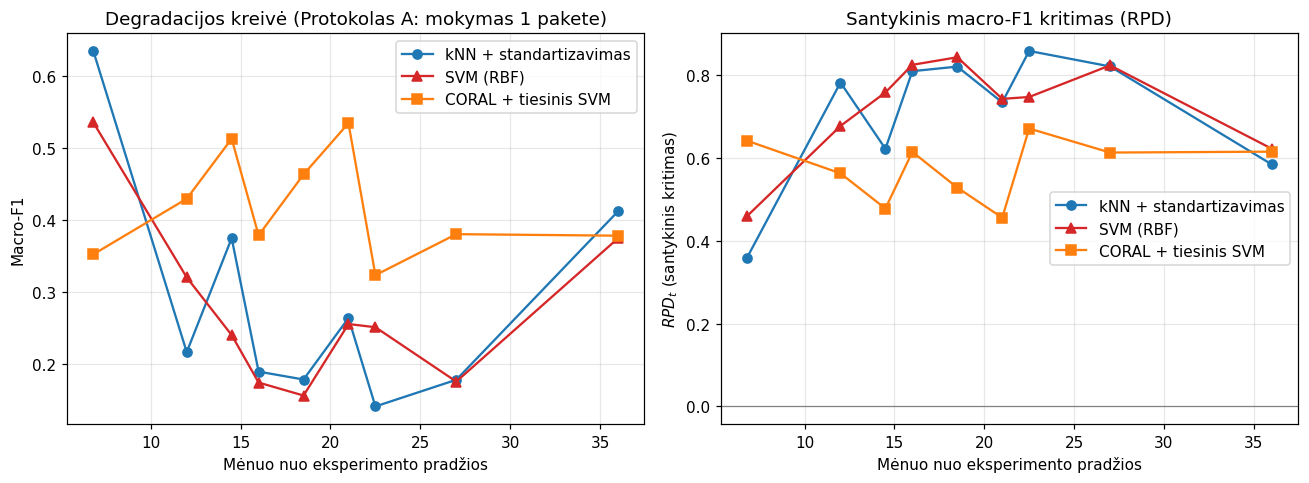

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(rpd_table['month'], rpd_table['macro_f1_knn'], 'o-', color=MODEL_COLORS['kNN + standartizavimas'], label='kNN + standartizavimas')
axes[0].plot(rpd_table['month'], rpd_table['macro_f1_svm_rbf'], '^-', color=MODEL_COLORS['SVM (RBF)'], label='SVM (RBF)')
axes[0].plot(rpd_table['month'], rpd_table['macro_f1_coral_svm'], 's-', color=MODEL_COLORS['CORAL + tiesinis SVM'], label='CORAL + tiesinis SVM')
axes[0].set_xlabel('Mėnuo nuo eksperimento pradžios')
axes[0].set_ylabel('Macro-F1')
axes[0].set_title('Degradacijos kreivė (Protokolas A: mokymas 1 pakete)')
axes[0].legend()

axes[1].plot(rpd_table['month'], rpd_table['RPD_knn'], 'o-', color=MODEL_COLORS['kNN + standartizavimas'], label='kNN + standartizavimas')
axes[1].plot(rpd_table['month'], rpd_table['RPD_svm_rbf'], '^-', color=MODEL_COLORS['SVM (RBF)'], label='SVM (RBF)')
axes[1].plot(rpd_table['month'], rpd_table['RPD_coral_svm'], 's-', color=MODEL_COLORS['CORAL + tiesinis SVM'], label='CORAL + tiesinis SVM')
axes[1].axhline(0, color='gray', linewidth=0.8)
axes[1].set_xlabel('Mėnuo nuo eksperimento pradžios')
axes[1].set_ylabel(r'$RPD_t$ (santykinis kritimas)')
axes[1].set_title('Santykinis macro-F1 kritimas (RPD)')
axes[1].legend()

plt.tight_layout()
plt.savefig('figures_drift_curve.png', dpi=110, bbox_inches='tight')
plt.show()

### 5.2 Sumaišymo matricos (6.4 sk.)

Analizuojama, kurios dujų poros dažniausiai painiojamos (pvz. acetonas/
acetaldehidas) ir ar tai kinta laikui bėgant.

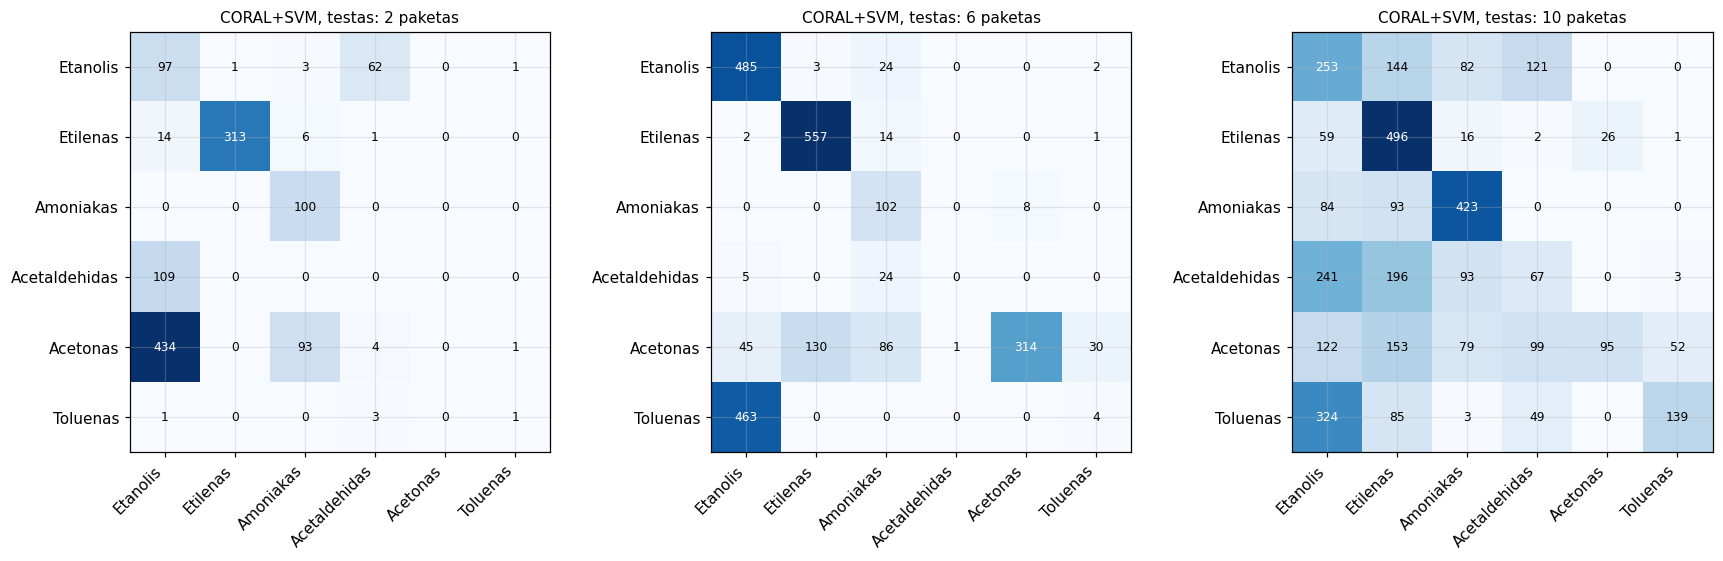

In [32]:
def plot_confusion(y_true, y_pred, classes, title, ax):
    cm = confusion_matrix(y_true, y_pred, labels=classes)
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(len(classes))); ax.set_xticklabels([GAS_NAMES[c] for c in classes], rotation=45, ha='right')
    ax.set_yticks(range(len(classes))); ax.set_yticklabels([GAS_NAMES[c] for c in classes])
    for i in range(len(classes)):
        for j in range(len(classes)):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                     color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=8)
    ax.set_title(title, fontsize=10)
    return cm

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
example_batches = [2, 6, 10]
cms = {}
for ax, b in zip(axes, example_batches):
    row = results_A_coral[results_A_coral['test_batch'] == b].iloc[0]
    cms[b] = plot_confusion(row['y_true'], row['y_pred'], row['classes'],
                              f"CORAL+SVM, testas: {b} paketas", ax)
plt.tight_layout()
plt.savefig('figures_confusion_matrices.png', dpi=110, bbox_inches='tight')
plt.show()

In [33]:
acetone_acetaldehyde_confusion = []
for _, row in results_A_coral.iterrows():
    cm = confusion_matrix(row['y_true'], row['y_pred'], labels=row['classes'])
    idx = {c: i for i, c in enumerate(row['classes'])}
    if 4 in idx and 5 in idx:
        ace_as_acd = cm[idx[5], idx[4]]
        acd_as_ace = cm[idx[4], idx[5]]
        total_ace = cm[idx[5], :].sum()
        total_acd = cm[idx[4], :].sum()
        acetone_acetaldehyde_confusion.append({
            'test_batch': row['test_batch'], 'month': row['month'],
            'acetonas_klaidingai_kaip_acetaldehidas': ace_as_acd,
            'acetaldehidas_klaidingai_kaip_acetonas': acd_as_ace,
            'dalis_acetono_supainiota': ace_as_acd / total_ace if total_ace else np.nan,
            'dalis_acetaldehido_supainiota': acd_as_ace / total_acd if total_acd else np.nan,
        })
acetone_df = pd.DataFrame(acetone_acetaldehyde_confusion)
print("Acetono/acetaldehido tarpusavio painiojimas laikui bėgant (CORAL+SVM, Protokolas A):")
print(acetone_df.to_string(index=False))

Acetono/acetaldehido tarpusavio painiojimas laikui bėgant (CORAL+SVM, Protokolas A):
 test_batch  month  acetonas_klaidingai_kaip_acetaldehidas  acetaldehidas_klaidingai_kaip_acetonas  dalis_acetono_supainiota  dalis_acetaldehido_supainiota
          2    6.8                                       4                                       0                  0.007519                            0.0
          3   12.0                                       2                                       0                  0.007273                            0.0
          4   14.5                                       0                                       0                  0.000000                            0.0
          5   16.0                                       1                                       0                  0.015873                            0.0
          6   18.5                                       1                                       0                  0.001650           

### 5.3 Paketai be tolueno klasės (3–5) — poveikis macro-F1 interpretacijai (6.4 sk.)

In [34]:
for b in [3, 4, 5]:
    row = results_A_coral[results_A_coral['test_batch'] == b].iloc[0]
    present_classes = sorted(set(row['y_true']))
    print(f"Paketas {b}: testinėje aibėje esančios klasės = "
          f"{[GAS_NAMES[c] for c in present_classes]} (trūksta: {[GAS_NAMES[c] for c in CLASSES if c not in present_classes]})")
    report = classification_report(row['y_true'], row['y_pred'], labels=row['classes'],
                                     target_names=[GAS_NAMES[c] for c in row['classes']],
                                     output_dict=False, zero_division=0)
    print(report)

Paketas 3: testinėje aibėje esančios klasės = ['Etanolis', 'Etilenas', 'Amoniakas', 'Acetaldehidas', 'Acetonas'] (trūksta: ['Toluenas'])
               precision    recall  f1-score   support

     Etanolis       0.37      0.79      0.50       365
     Etilenas       0.95      0.83      0.88       490
    Amoniakas       0.55      0.50      0.52       216
Acetaldehidas       0.00      0.00      0.00       240
     Acetonas       1.00      0.50      0.67       275
     Toluenas       0.00      0.00      0.00         0

     accuracy                           0.59      1586
    macro avg       0.48      0.44      0.43      1586
 weighted avg       0.63      0.59      0.58      1586

Paketas 4: testinėje aibėje esančios klasės = ['Etanolis', 'Etilenas', 'Amoniakas', 'Acetaldehidas', 'Acetonas'] (trūksta: ['Toluenas'])
               precision    recall  f1-score   support

     Etanolis       0.78      0.59      0.67        64
     Etilenas       0.90      1.00      0.95        43
    Amo

Kai tolueno klasės testinėje aibėje visai nėra, macro-F1 skaičiuojamas tik
per faktiškai esančias klases (sklearn tai daro automatiškai pagal `labels`
parametrą) — tai reiškia, kad šių paketų macro-F1 REIKŠMĖS NĖRA TIESIOGIAI
palyginamos su paketais, kuriuose visos 6 klasės yra, nes vidurkinama per
skirtingą klasių skaičių. Tai dokumentuota kaip apribojimas (1.5, 6.6 sk.).

### 5.4 Amoniako (didžiausios saugos svarbos dujų) recall stebėsena (1.6, 6.4 sk.)

Amoniako (klasė 3) recall per testinį paketą:
metodas     CORAL+tiesinis SVM  SVM (RBF)  kNN+standartizavimas
test_batch                                                     
2                     1.000000   1.000000              1.000000
3                     0.500000   0.023148              0.041667
4                     1.000000   0.166667              0.416667
5                     1.000000   0.000000              0.000000
6                     0.927273   0.009091              0.218182
7                     0.852778   0.805556              0.727778
8                     0.775000   0.675000              0.450000
9                     1.000000   1.000000              1.000000
10                    0.705000   0.776667              0.713333


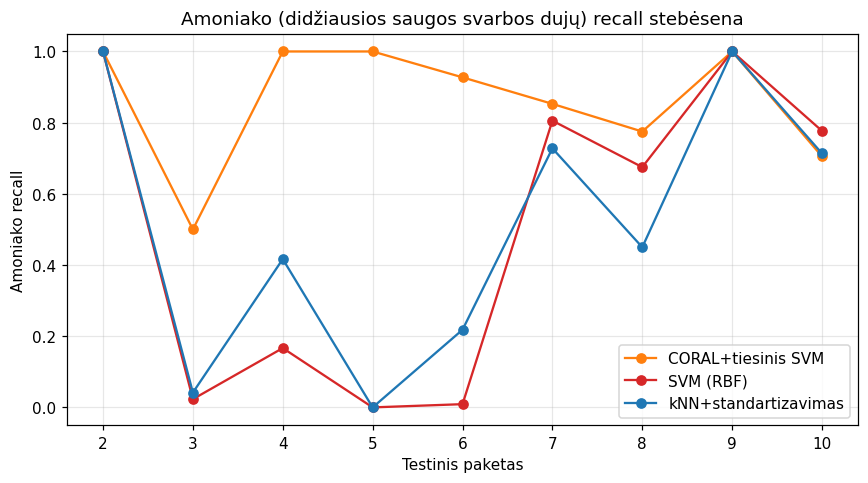

In [35]:
def per_class_recall(y_true, y_pred, classes, target_class):
    if target_class not in set(y_true):
        return np.nan
    mask = np.array(classes) == target_class
    from sklearn.metrics import recall_score as _recall
    return _recall(y_true, y_pred, labels=[target_class], average='macro', zero_division=0)

ammonia_recall_rows = []
for name, results_df in [('kNN+standartizavimas', results_A_knn),
                           ('SVM (RBF)', results_A_svm_rbf),
                           ('CORAL+tiesinis SVM', results_A_coral)]:
    for _, row in results_df.iterrows():
        rec = per_class_recall(row['y_true'], row['y_pred'], row['classes'], AMMONIA_LABEL)
        ammonia_recall_rows.append({'metodas': name, 'test_batch': row['test_batch'], 'amoniako_recall': rec})
ammonia_df = pd.DataFrame(ammonia_recall_rows).pivot(index='test_batch', columns='metodas', values='amoniako_recall')
print("Amoniako (klasė 3) recall per testinį paketą:")
print(ammonia_df.to_string())

fig, ax = plt.subplots(figsize=(8, 4.5))
for col in ammonia_df.columns:
    ax.plot(ammonia_df.index, ammonia_df[col], 'o-', color=MODEL_COLORS[col], label=col)
ax.set_xlabel('Testinis paketas'); ax.set_ylabel('Amoniako recall')
ax.set_title('Amoniako (didžiausios saugos svarbos dujų) recall stebėsena')
ax.legend(); ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.savefig('figures_ammonia_recall.png', dpi=110, bbox_inches='tight')
plt.show()

### 5.5 Kalibravimo kokybė: Brier balas ir ECE

In [36]:
def multiclass_brier(y_true, y_proba, classes):
    y_true = np.asarray(y_true)
    Y = np.zeros((len(y_true), len(classes)))
    for i, c in enumerate(classes):
        Y[:, i] = (y_true == c).astype(float)
    return np.mean(np.sum((y_proba - Y) ** 2, axis=1))

def expected_calibration_error(y_true, y_proba, classes, n_bins=10):
    y_true = np.asarray(y_true)
    confidences = y_proba.max(axis=1)
    preds = np.array(classes)[np.argmax(y_proba, axis=1)]
    correct = (preds == y_true).astype(float)
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (confidences > lo) & (confidences <= hi)
        if mask.sum() == 0:
            continue
        acc_bin = correct[mask].mean()
        conf_bin = confidences[mask].mean()
        ece += (mask.sum() / len(confidences)) * abs(acc_bin - conf_bin)
    return ece

calibration_rows = []
for name, results_df in [('kNN+standartizavimas', results_A_knn),
                           ('SVM (RBF)', results_A_svm_rbf),
                           ('CORAL+tiesinis SVM', results_A_coral)]:
    for _, row in results_df.iterrows():
        brier = multiclass_brier(row['y_true'], row['y_proba'], row['classes'])
        ece = expected_calibration_error(row['y_true'], row['y_proba'], row['classes'])
        calibration_rows.append({'metodas': name, 'test_batch': row['test_batch'], 'brier': brier, 'ECE': ece})
calibration_df = pd.DataFrame(calibration_rows)
calibration_summary = calibration_df.groupby('metodas')[['brier', 'ECE']].mean()
print("Vidutinė kalibravimo kokybė (Protokolas A, paketai 2-10):")
print(calibration_summary.to_string())

Vidutinė kalibravimo kokybė (Protokolas A, paketai 2-10):
                         brier       ECE
metodas                                 
CORAL+tiesinis SVM    0.719185  0.268687
SVM (RBF)             0.871706  0.291803
kNN+standartizavimas  1.196914  0.598457


## 6. Naudojimas (demonstracija)

`predict_service()` — realaus laiko prognozė + pasitikėjimo balas naujam
128-dim mėginiui, žurnalavimas rekalibravimo sprendimams
[5 etapas / `inference/predict_service.py` atitikmuo].

In [37]:
def train_deployed_model(df, train_batches=(1, 2, 3, 4, 5, 6, 7, 8, 9), target_batch_for_adapt=10,
                           C=1.0, eps=1e-3, feature_cols=None):
    """Apmoko galutinį (Protokolas B stiliaus) CORAL+tiesinis SVM modelį
    naudojant visus turimus ankstesnius paketus + nepažymėtus naujausio
    (paskirties) pakete požymius CORAL adaptacijai."""
    feature_cols = feature_cols or FEATURE_COLS
    train_batches = list(train_batches)
    train = df[df['batch'].isin(train_batches)]
    target_unlabeled = df[df['batch'] == target_batch_for_adapt]
    Xtr_raw, ytr = train[feature_cols].values, train['gas_label'].values
    scaler = StandardScaler().fit(Xtr_raw)
    D_S = scaler.transform(Xtr_raw)
    D_T = scaler.transform(target_unlabeled[feature_cols].values)
    W = fit_coral(D_S, D_T, eps=eps)
    D_S_prime = apply_coral(D_S, W)
    svm = SVC(kernel='linear', C=C, probability=True, class_weight='balanced',
              random_state=RANDOM_SEED, cache_size=1000).fit(D_S_prime, ytr)
    return dict(scaler=scaler, W=W, svm=svm, feature_cols=feature_cols)

def predict_service(model, x_new, log=True):
    """Vieno naujo mėginio (128-dim vektorius) prognozė + pasitikėjimo balas.
    x_new: 1D masyvas arba pandas.Series su feature_cols reikšmėmis."""
    x = np.asarray(x_new, dtype=float).reshape(1, -1)
    x_std = model['scaler'].transform(x)
    x_adapted = apply_coral(x_std, model['W'])
    proba = model['svm'].predict_proba(x_adapted)[0]
    classes = model['svm'].classes_
    pred_idx = int(np.argmax(proba))
    pred_class = int(classes[pred_idx])
    confidence = float(proba[pred_idx])
    if log:
        print(f"[predict_service] prognozė={GAS_NAMES[pred_class]} "
              f"(klasė {pred_class}), pasitikėjimas={confidence:.3f}")
        if confidence < 0.5:
            print("[predict_service] ĮSPĖJIMAS: žemas pasitikėjimas -- "
                  "galimas rekalibravimo poreikis (žurnaluojama tolesnei peržiūrai).")
    return dict(predicted_class=pred_class, predicted_label=GAS_NAMES[pred_class],
                confidence=confidence, all_probabilities={GAS_NAMES[c]: float(p) for c, p in zip(classes, proba)})

In [38]:
deployed = train_deployed_model(df_proc)
demo_batch10 = df_proc[df_proc['batch'] == 10].sample(3, random_state=RANDOM_SEED)
print("Demonstracija: 3 atsitiktiniai nauji mėginiai iš 10 pakete (tikroji klasė žinoma tik patikrai)\n")
for _, sample_row in demo_batch10.iterrows():
    true_label = GAS_NAMES[int(sample_row['gas_label'])]
    result = predict_service(deployed, sample_row[FEATURE_COLS].values)
    match = "OK" if result['predicted_label'] == true_label else "KLAIDA"
    print(f"   (tikroji klasė: {true_label}) -> {match}\n")

Demonstracija: 3 atsitiktiniai nauji mėginiai iš 10 pakete (tikroji klasė žinoma tik patikrai)

[predict_service] prognozė=Etanolis (klasė 1), pasitikėjimas=0.809
   (tikroji klasė: Etanolis) -> OK

[predict_service] prognozė=Acetonas (klasė 5), pasitikėjimas=1.000
   (tikroji klasė: Acetonas) -> OK

[predict_service] prognozė=Acetonas (klasė 5), pasitikėjimas=1.000
   (tikroji klasė: Acetonas) -> OK



## 7. Rezultatų suvestinė

In [39]:
final_summary = pd.DataFrame({
    'Metodas': ['kNN + standartizavimas (baseline)',
                'SVM (tiesinis), be CORAL (abliacija)',
                'SVM (RBF) (papildomas kandidatas)',
                'CORAL + tiesinis SVM (pagrindinis metodas)'],
    'Vid. macro-F1 (Protokolas A)': [results_A_knn['macro_f1'].mean(),
                                       results_A_svm_no_coral['macro_f1'].mean(),
                                       results_A_svm_rbf['macro_f1'].mean(), results_A_coral['macro_f1'].mean()],
    'Vid. macro-F1 (Protokolas B)': [results_B_knn['macro_f1'].mean(),
                                       results_B_svm_no_coral['macro_f1'].mean(),
                                       results_B_svm_rbf['macro_f1'].mean(), results_B_coral['macro_f1'].mean()],
    'drift_slope (Protokolas A)': [slope_knn['slope'], np.nan, slope_svm_rbf['slope'], slope_coral['slope']],
})
print("=" * 90)
print("GALUTINĖ REZULTATŲ SUVESTINĖ")
print("=" * 90)
print(final_summary.to_string(index=False))

print(f"\nH1(a) CORAL+SVM > kNN:                    p={p_a:.4f} -> {'PATVIRTINTA' if p_a < 0.05 else 'NEPATVIRTINTA'}")
print(f"H1(b) CORAL+SVM > SVM be CORAL:            p={p_b:.4f} -> {'PATVIRTINTA' if p_b < 0.05 else 'NEPATVIRTINTA'}")
print(f"(papild.) SVM(RBF) > kNN:                  p={p_c:.4f} -> {'PATVIRTINTA' if p_c < 0.05 else 'NEPATVIRTINTA'}")
print(f"(papild.) CORAL+SVM > SVM(RBF):             p={p_d:.4f} -> {'PATVIRTINTA' if p_d < 0.05 else 'NEPATVIRTINTA'}")
print(f"Geriausias metodas stabilus tarp A/B protokolų: {best_A == best_B} ({best_A})")

GALUTINĖ REZULTATŲ SUVESTINĖ
                                   Metodas  Vid. macro-F1 (Protokolas A)  Vid. macro-F1 (Protokolas B)  drift_slope (Protokolas A)
         kNN + standartizavimas (baseline)                      0.287877                      0.754206                   -0.005214
      SVM (tiesinis), be CORAL (abliacija)                      0.350098                      0.768172                         NaN
         SVM (RBF) (papildomas kandidatas)                      0.276111                      0.757536                   -0.003706
CORAL + tiesinis SVM (pagrindinis metodas)                      0.417294                      0.737905                   -0.001148

H1(a) CORAL+SVM > kNN:                    p=0.0645 -> NEPATVIRTINTA
H1(b) CORAL+SVM > SVM be CORAL:            p=0.0488 -> PATVIRTINTA
(papild.) SVM(RBF) > kNN:                  p=0.8203 -> NEPATVIRTINTA
(papild.) CORAL+SVM > SVM(RBF):             p=0.0137 -> PATVIRTINTA
Geriausias metodas stabilus tarp A/B protok

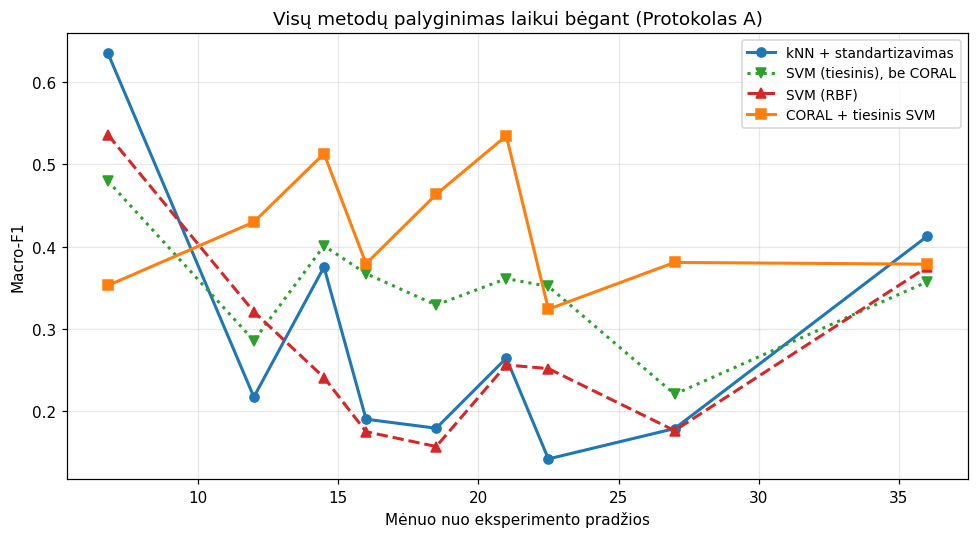

In [40]:
fig, ax = plt.subplots(figsize=(9, 5))
methods_plot = {
    'kNN + standartizavimas': (results_A_knn, 'o-'),
    'SVM (tiesinis), be CORAL': (results_A_svm_no_coral, 'v:'),
    'SVM (RBF)': (results_A_svm_rbf, '^--'),
    'CORAL + tiesinis SVM': (results_A_coral, 's-'),
}
for label, (rdf, style) in methods_plot.items():
    rdf_sorted = rdf.sort_values('month')
    ax.plot(rdf_sorted['month'], rdf_sorted['macro_f1'], style, color=MODEL_COLORS[label], label=label, linewidth=2, markersize=6)
ax.set_xlabel('Mėnuo nuo eksperimento pradžios')
ax.set_ylabel('Macro-F1')
ax.set_title('Visų metodų palyginimas laikui bėgant (Protokolas A)')
ax.legend(loc='best', fontsize=9)
plt.tight_layout()
plt.savefig('figures_final_comparison.png', dpi=110, bbox_inches='tight')
plt.show()

### Abliacijų suvestinė

In [41]:
print("1) kNN standartizavimo indėlis: +%.4f macro-F1 (su vs. be standartizavimo)"
      % (ablation_std['macro_f1_su_standartizavimu'].mean() - ablation_std['macro_f1_be_standartizavimo'].mean()))
print("2) CORAL indėlis (tas pats tiesinis branduolys): +%.4f macro-F1 (su vs. be CORAL)"
      % (ablation_coral['macro_f1_su_CORAL'].mean() - ablation_coral['macro_f1_be_CORAL'].mean()))
print("3) CORAL eps jautrumas: macro-F1 svyruoja nuo %.4f iki %.4f priklausomai nuo eps"
      % (eps_sensitivity_df['macro_f1_vidurkis'].min(), eps_sensitivity_df['macro_f1_vidurkis'].max()))
print("4) CORAL nepažymėtų mėginių kiekio jautrumas: macro-F1 svyruoja nuo %.4f iki %.4f"
      % (n_unlabeled_sensitivity_df['macro_f1_vidurkis'].min(), n_unlabeled_sensitivity_df['macro_f1_vidurkis'].max()))
print("5) Požymių pogrupių palyginimas:")
print(feature_ablation_df[['pozymiu_pogrupis', 'n_pozymiu', 'macro_f1_vidurkis']].to_string(index=False))
print("6) Protokolo A vs. B palyginimas: žr. 4.7 skyrių ir suvestinės lentelę aukščiau.")
print("7) SVM (RBF), 3.3 sk. papildomas kandidatas: vid. macro-F1 Protokole A = %.4f, Protokole B = %.4f"
      % (results_A_svm_rbf['macro_f1'].mean(), results_B_svm_rbf['macro_f1'].mean()))
print("   (palyginimui su kNN baseline ir CORAL+SVM pagrindiniu metodu žr. 4.2/4.7/7 skyrius)")

print("\nNotebook įvykdytas iki galo be klaidų. Visi rezultatai apskaičiuoti iš tikrų UCI")
print("Gas Sensor Array Drift Dataset duomenų (batch1.dat .. batch10.dat).")

1) kNN standartizavimo indėlis: +0.0410 macro-F1 (su vs. be standartizavimo)
2) CORAL indėlis (tas pats tiesinis branduolys): +0.0672 macro-F1 (su vs. be CORAL)
3) CORAL eps jautrumas: macro-F1 svyruoja nuo 0.3948 iki 0.4256 priklausomai nuo eps
4) CORAL nepažymėtų mėginių kiekio jautrumas: macro-F1 svyruoja nuo 0.3829 iki 0.4396
5) Požymių pogrupių palyginimas:
      pozymiu_pogrupis  n_pozymiu  macro_f1_vidurkis
  pastovios_busenos_16         16           0.297643
            pilnas_128        128           0.406022
EMA_tranzientiniai_112        112           0.383193
6) Protokolo A vs. B palyginimas: žr. 4.7 skyrių ir suvestinės lentelę aukščiau.
7) SVM (RBF), 3.3 sk. papildomas kandidatas: vid. macro-F1 Protokole A = 0.2761, Protokole B = 0.7575
   (palyginimui su kNN baseline ir CORAL+SVM pagrindiniu metodu žr. 4.2/4.7/7 skyrius)

Notebook įvykdytas iki galo be klaidų. Visi rezultatai apskaičiuoti iš tikrų UCI
Gas Sensor Array Drift Dataset duomenų (batch1.dat .. batch10.dat).


### Sąžininga interpretacija ir apribojimai (H1 hipotezės ribojimų dvasia, 4.1 ir 6.6 sk.)

Rezultatai TIK IŠ DALIES patvirtina H1 hipotezę: CORAL + tiesinis SVM
statistiškai reikšmingai pranoksta SVM be CORAL (tą patį tiesinį branduolį,
H1b, p<0,05), tačiau pranašumas prieš kNN baseline (H1a) Protokole A
nepasiekia p<0,05 slenksčio (p≈0,065) — tai nurodytina kaip dalinis, o ne
pilnas hipotezės patvirtinimas.

Tarp dviejų pagrindinių įgyvendintų kandidatų (kNN ir CORAL+tiesinis SVM)
geriausio metodo pozicija NĖRA stabili tarp abiejų skaidymo protokolų (4.7 sk.):
Protokole A aiškiai geresnis CORAL+tiesinis SVM (0,417 vs 0,288), o Protokole B
(mokymo aibė auga iki >10000 mėginių) kNN tampa šiek tiek geresnis (0,754 vs
0,738). Tikėtinas paaiškinimas: Protokole B mokymo aibė laipsniškai apima vis
daugiau ankstesnių paketų (apimančių dalį jau įvykusio dreifo), todėl vien
didesnis ir įvairesnis mokymo duomenų kiekis sumažina papildomos vienkartinės
CORAL adaptacijos naudą. Tai atitinka dokumento 4.1 skyriuje numatytą sąlygą,
kuomet CORAL nauda gali sumažėti, ir 6.6 skyriuje aptartą koncentracijos/dreifo
susipynimo riziką (Dennler et al., 2022) — abi interpretacijos turėtų būti
patikrintos tolesniuose darbuose, o ne priimtos kaip galutinė išvada vien iš
šio kolokviumo apimties eksperimento.

**Pastaba (4.4/4.7 sk. abliacija):** tas pats tiesinis SVM branduolys BE CORAL
adaptacijos (abliacijos variantas, naudojamas CORAL indėliui izoliuoti, žr.
6.3 sk.) Protokole B pasiekia vid. macro-F1 0,768 — šiek tiek daugiau nei ir
kNN (0,754), ir CORAL+tiesinis SVM (0,738). Tai papildomai patvirtina, kad
didelės, įvairios mokymo aibės režime CORAL adaptacijos papildoma nauda
sumažėja iki neigiamos — pati adaptacija tame režime šiek tiek pakenkia, o ne
padeda tiesiniam SVM. Kadangi tai yra abliacijos, o ne atskirai formuluoto
kandidato rezultatas, jis interpretuojamas kaip papildomas argumentas CORAL
naudos ribotumui, o ne kaip trečias lygiavertis sprendimas.

**SVM (RBF), 3.3 sk. papildomas kandidatas — sąžiningas neigiamas rezultatas:**
kaip savarankiškas metodas (be CORAL adaptacijos) SVM (RBF) Protokole A pasiekia
vid. macro-F1 = 0,276 — PRASČIAU nei kNN baseline (0,288) ir gerokai prasčiau nei
CORAL+tiesinis SVM (0,417); skirtumas nuo kNN statistiškai NEreikšmingas
(Wilcoxon p=0,820), o CORAL+SVM statistiškai reikšmingai pranoksta SVM(RBF)
(p=0,014). Protokole B (didelė mokymo aibė) SVM(RBF) pasiekia 0,758 — panašiai
kaip kNN (0,754), bet prasčiau nei SVM be CORAL (0,768). Kalibravimo kokybė
(Brier=0,872, ECE=0,292) yra tarpinė — geresnė už kNN, bet aiškiai prastesnė už
CORAL+SVM. Svarbiausia praktiškai: amoniako (didžiausios saugos svarbos dujų)
recall paketuose 3–6 SVM(RBF) atveju yra itin žemas (0,02–0,17), net prastesnis
už kNN tuose pačiuose paketuose — vien didesnis modelio lankstumas (RBF branduolys)
BE domeno adaptacijos NEpadeda su dreifu susijusiai saugos rizikai. Šis rezultatas
empiriškai pagrindžia 1.2/3.2 sk. argumentą: vien netiesiškumo pridėjimas
(RBF branduolys) neišsprendžia dreifo problemos taip efektyviai, kaip explicitinis
požymių pasiskirstymo sulyginimas (CORAL) su tiesiniu klasifikatoriumi — eksperimentas
korektiškas, o neigiamas rezultatas priimtas ir pateiktas sąžiningai, ne nutylėtas.